# Modelo multicriterio para la priorización de manzanas con potencial de renovación urbana en Bogotá

Este cuaderno desarrolla el flujo analítico para identificar manzanas con potencial de renovación urbana en Bogotá a partir de variables territoriales derivadas del cruce entre información del POT de Bogotá y el Censo Nacional de Población y Vivienda 2018 del DANE.

El análisis se estructura en cuatro etapas:
1. Carga y revisión del dataset procesado espacialmente en ArcGIS.
2. Selección de manzanas calificables a partir del filtro normativo.
3. Análisis exploratorio, normalización y exploración tipológica mediante clustering.
4. Construcción del índice multicriterio de renovación urbana y clasificación final de prioridades.

Los resultados finales se exportan para su posterior unión espacial en ArcGIS mediante el campo `cod_dane`.

## Carga del dataset base

El dataset de entrada fue construido previamente en ArcGIS mediante el cruce entre la capa del POT de Bogotá y la capa del Censo Nacional de Población y Vivienda 2018 del DANE. En esta etapa ya se encuentran calculadas las variables territoriales y las exclusiones normativas.

LIBRERÍAS

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Estructura del dataset de entrada

El dataset incluye variables de identificación espacial, variables urbanas originales y variables de exclusión normativa construidas previamente en ArcGIS.

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
df = pd.read_excel("manzanas_ae.xlsx")

In [11]:
df = pd.read_excel("manzanas_ae.xlsx")
df.head()

,objectid,man_codigo,actuacion_estrategica,ae_priorizada,cod_dane,area_manzana,densidad,viviendas,poblacion,dist_tm,...,viviendas_desocupadas,tiene_parque,tiene_equipa_pub,tiene_esp_pub,tiene_aim,plan_parcial_excluido,estado_pp,tiene_bic,sum_exclusiones,calificables
0,1,8544012,Lagos de Torca,0,1100110000000085330115,9850.528979,0.048472,190.0,492.0,211.750049,...,1.0,0.0,0.0,0.0,0.0,0.0,Ninguno,0.0,0.0,1.0
1,2,8519059,Nodo Toberin,0,1100110000000085190312,3952.997481,0.013165,20.0,52.0,826.160220,...,2.0,0.0,0.0,0.0,0.0,0.0,Ninguno,0.0,0.0,1.0
2,3,8516029,Nodo Toberin,0,1100110000000085160107,6712.437990,0.027434,50.0,184.0,773.151617,...,2.0,0.0,0.0,0.0,0.0,0.0,Ninguno,0.0,0.0,1.0
3,4,8516019,Nodo Toberin,0,1100110000000085160201,21563.511592,0.038000,325.0,822.0,567.918018,...,6.0,0.0,0.0,0.0,0.0,0.0,Ninguno,0.0,0.0,1.0
4,5,8501008,Nodo Toberin,0,1100110000000085010206,17517.294260,0.005901,47.0,100.0,238.909162,...,0.0,0.0,0.0,0.0,0.0,0.0,Ninguno,0.0,0.0,1.0


## Estructura del dataset de entrada

El dataset incluye variables de identificación espacial, variables urbanas originales y variables de exclusión normativa construidas previamente en ArcGIS.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   objectid               3400 non-null   int64  
 1   man_codigo             3400 non-null   int64  
 2   actuacion_estrategica  3400 non-null   object 
 3   ae_priorizada          3400 non-null   int64  
 4   cod_dane               3234 non-null   object 
 5   area_manzana           3400 non-null   float64
 6   densidad               3234 non-null   float64
 7   viviendas              3234 non-null   float64
 8   poblacion              3234 non-null   float64
 9   dist_tm                3234 non-null   float64
 10  mix_uso                3234 non-null   float64
 11  cantidad_encuestas     3234 non-null   float64
 12  uso_residencial        3234 non-null   float64
 13  uso_industrial         3234 non-null   float64
 14  uso_comercial          3234 non-null   float64
 15  vivi

In [13]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
objectid,3400.0,NaN,NaN,NaN,1700.5,981.639785,1.0,850.75,1700.5,2550.25,3400.0
man_codigo,3400.0,NaN,NaN,NaN,7761311.497059,17462955.939879,1114009.0,5203010.75,6308012.5,7305018.25,208132004.0
actuacion_estrategica,3400,25,Distrito Aeroportuario Fontibón,558,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ae_priorizada,3400.0,NaN,NaN,NaN,0.570588,0.495065,0.0,0.0,1.0,1.0,1.0
cod_dane,3234,3124,1100110000000091240205,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_manzana,3400.0,NaN,NaN,NaN,10864.846612,54848.438064,96.10798,2074.980665,3941.601674,7110.266263,1710036.543282
densidad,3234.0,NaN,NaN,NaN,0.03988,0.039131,0.0,0.004947,0.02762,0.06598,0.19795
viviendas,3234.0,NaN,NaN,NaN,48.575758,65.757693,0.0,12.0,34.0,61.0,1031.0
poblacion,3234.0,NaN,NaN,NaN,132.54731,161.676168,0.0,32.0,99.0,182.0,2561.0
dist_tm,3234.0,NaN,NaN,NaN,462.132294,643.725643,0.0,182.818831,311.850959,548.933389,5172.947259


## Revisión de valores faltantes

Se identifican posibles valores nulos en las variables del modelo para documentar la calidad de la información antes de la normalización y el cálculo del índice.

In [14]:
df.isnull().sum()

,0
objectid,0
man_codigo,0
actuacion_estrategica,0
ae_priorizada,0
cod_dane,166
area_manzana,0
densidad,166
viviendas,166
poblacion,166
dist_tm,166


In [15]:
total_manzanas = len(df)
manzanas_con_nulos = df.isnull().any(axis=1).sum()
porcentaje_nulos = manzanas_con_nulos / total_manzanas * 100

print(f"Total de manzanas: {total_manzanas}")
print(f"Manzanas con al menos un valor nulo: {manzanas_con_nulos}")
print(f"Porcentaje de manzanas con nulos: {porcentaje_nulos:.2f}%")

Total de manzanas: 3400
Manzanas con al menos un valor nulo: 166
Porcentaje de manzanas con nulos: 4.88%


Los valores nulos identificados corresponden principalmente a manzanas que no presentaron correspondencia espacial en el cruce con información censal del DANE y la información del POT.

In [16]:
df = df.dropna().copy()
print("Total de manzanas después de eliminar nulos:", df.shape)

Total de manzanas después de eliminar nulos: (3234, 25)


## Variables relevantes para el modelo

Las variables principales del análisis son:

- `viviendas_desocupadas`: aproximación a vacancia residencial.
- `densidad`: densidad poblacional por manzana.
- `dist_tm`: distancia al sistema de transporte masivo.
- `mix_uso`: indicador de mezcla de usos del suelo.

Adicionalmente, el dataset contiene variables de exclusión normativa derivadas del procesamiento espacial en ArcGIS.

## Filtro normativo territorial

Antes de aplicar el modelo, se verifica la variable `calificables`, construida a partir de la suma de exclusiones normativas tales como presencia de parques, equipamientos públicos, espacio público, áreas de interés ambiental, planes parciales excluidos y bienes de interés cultural.

Solo las manzanas con `calificables = 1` se incluyen en el análisis del índice.

In [17]:
df["calificables"].value_counts()

,count
calificables,
1.0,2228
0.0,1006


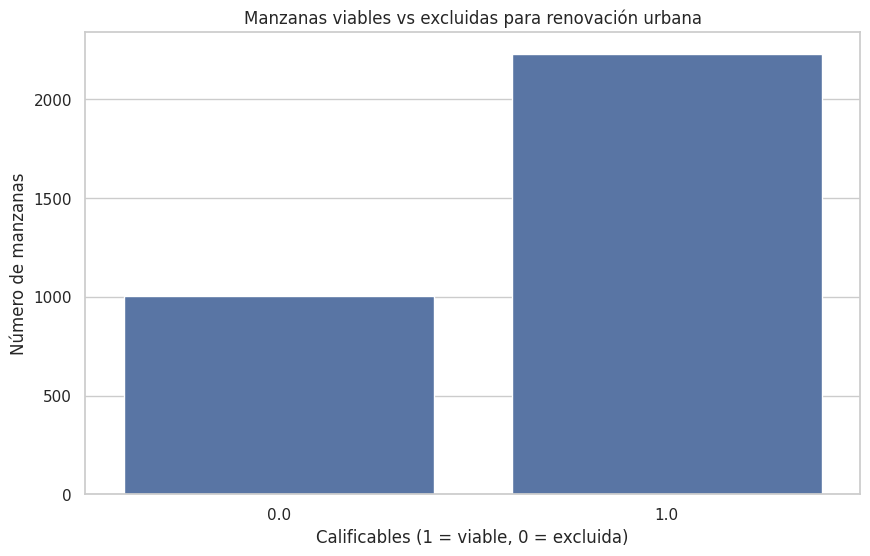

In [18]:
sns.countplot(x="calificables", data=df)
plt.title("Manzanas viables vs excluidas para renovación urbana")
plt.xlabel("Calificables (1 = viable, 0 = excluida)")
plt.ylabel("Número de manzanas")
plt.show()

In [19]:
cols_normativas = [
    "tiene_parque",
    "tiene_equipa_pub",
    "tiene_esp_pub",
    "tiene_aim",
    "plan_parcial_excluido",
    "tiene_bic"
]

df[cols_normativas].sum().sort_values(ascending=False)

,0
tiene_parque,441.0
tiene_aim,240.0
tiene_equipa_pub,202.0
tiene_bic,155.0
plan_parcial_excluido,105.0
tiene_esp_pub,25.0


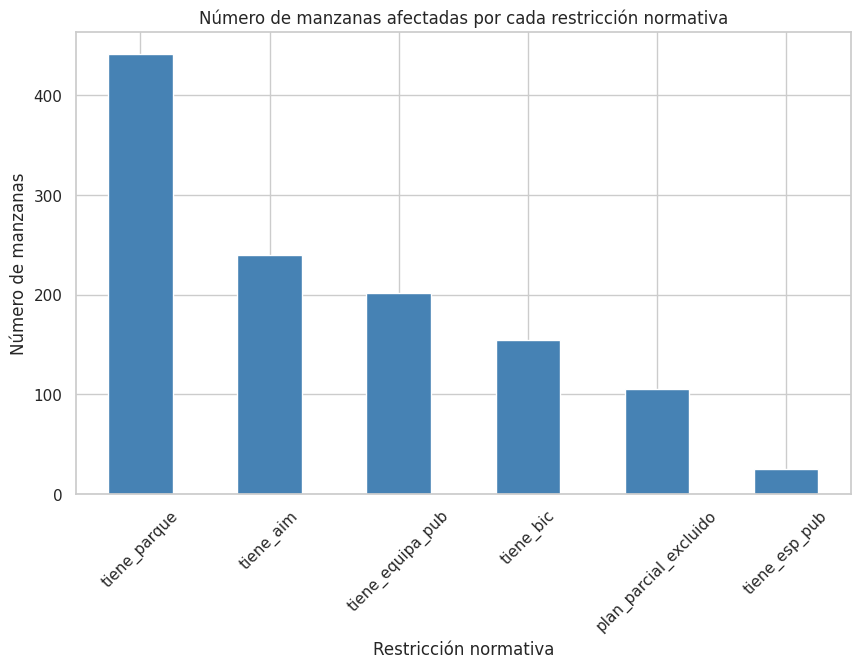

In [20]:
causas_exclusion = df[cols_normativas].sum().sort_values(ascending=False)

causas_exclusion.plot(kind="bar", color="steelblue")
plt.title("Número de manzanas afectadas por cada restricción normativa")
plt.xlabel("Restricción normativa")
plt.ylabel("Número de manzanas")
plt.xticks(rotation=45)
plt.show()

In [21]:
df["sum_exclusiones"].value_counts(dropna=False).sort_index()

,count
sum_exclusiones,
0.0,2228
1.0,860
2.0,131
3.0,14
4.0,1


### Interpretación del análisis normativo

Las variables normativas no se incorporan directamente al modelo de clustering, pero sí son fundamentales para construir el filtro urbano previo. Estas variables permiten excluir manzanas que no pueden ser objeto de renovación urbana por restricciones como presencia de parques, equipamientos, espacio público, áreas de interés ambiental, planes parciales vigentes o bienes de interés cultural.

La variable `mix_uso` se construyó como la suma de unidades no residenciales con uso comercial e industrial. Por esta razón, no representa un índice clásico de mezcla de usos del suelo, sino un indicador proxy de actividad económica no residencial en la manzana.

Esta variable se incorpora al análisis con el fin de capturar la presencia de funciones económicas urbanas que pueden incidir en el potencial de transformación del territorio.

FILTRAR MANZANAS VIABLES

In [22]:
df_modelo = df[df["calificables"] == 1].copy()
print("Manzanas viables para modelación:", df_modelo.shape)

Manzanas viables para modelación: (2228, 25)


## Selección de variables urbanas para análisis

Se utilizan variables urbanas y demográficas que permiten caracterizar intensidad urbana, accesibilidad, estructura física de la manzana y vacancia residencial.

In [23]:
variables = [
    "area_manzana",
    "densidad",
    "viviendas",
    "poblacion",
    "dist_tm",
    "mix_uso",
    "viviendas_desocupadas"
]

variables

['area_manzana',
 'densidad',
 'viviendas',
 'poblacion',
 'dist_tm',
 'mix_uso',
 'viviendas_desocupadas']

In [24]:
df_modelo[variables].describe().round(3)

,area_manzana,densidad,viviendas,poblacion,dist_tm,mix_uso,viviendas_desocupadas
count,2228.000,2228.000,2228.000,2228.00,2228.000,2228.000,2228.000
mean,6443.119,0.045,48.119,135.73,459.182,6.403,2.089
std,16463.472,0.040,51.549,137.04,594.588,8.489,4.296
min,119.998,0.000,0.000,0.00,0.000,0.000,0.000
25%,2059.153,0.011,19.000,49.00,202.006,1.000,0.000
50%,3592.836,0.035,38.000,112.00,325.295,3.000,1.000
75%,6245.571,0.075,63.000,188.25,567.967,9.000,3.000
max,478727.446,0.198,901.000,2561.00,5172.947,62.000,95.000


## Distribución de variables urbanas. Histogramas

Se analiza la distribución de las variables urbanas mediante histogramas, con el fin de identificar sesgos, concentraciones y comportamientos extremos.

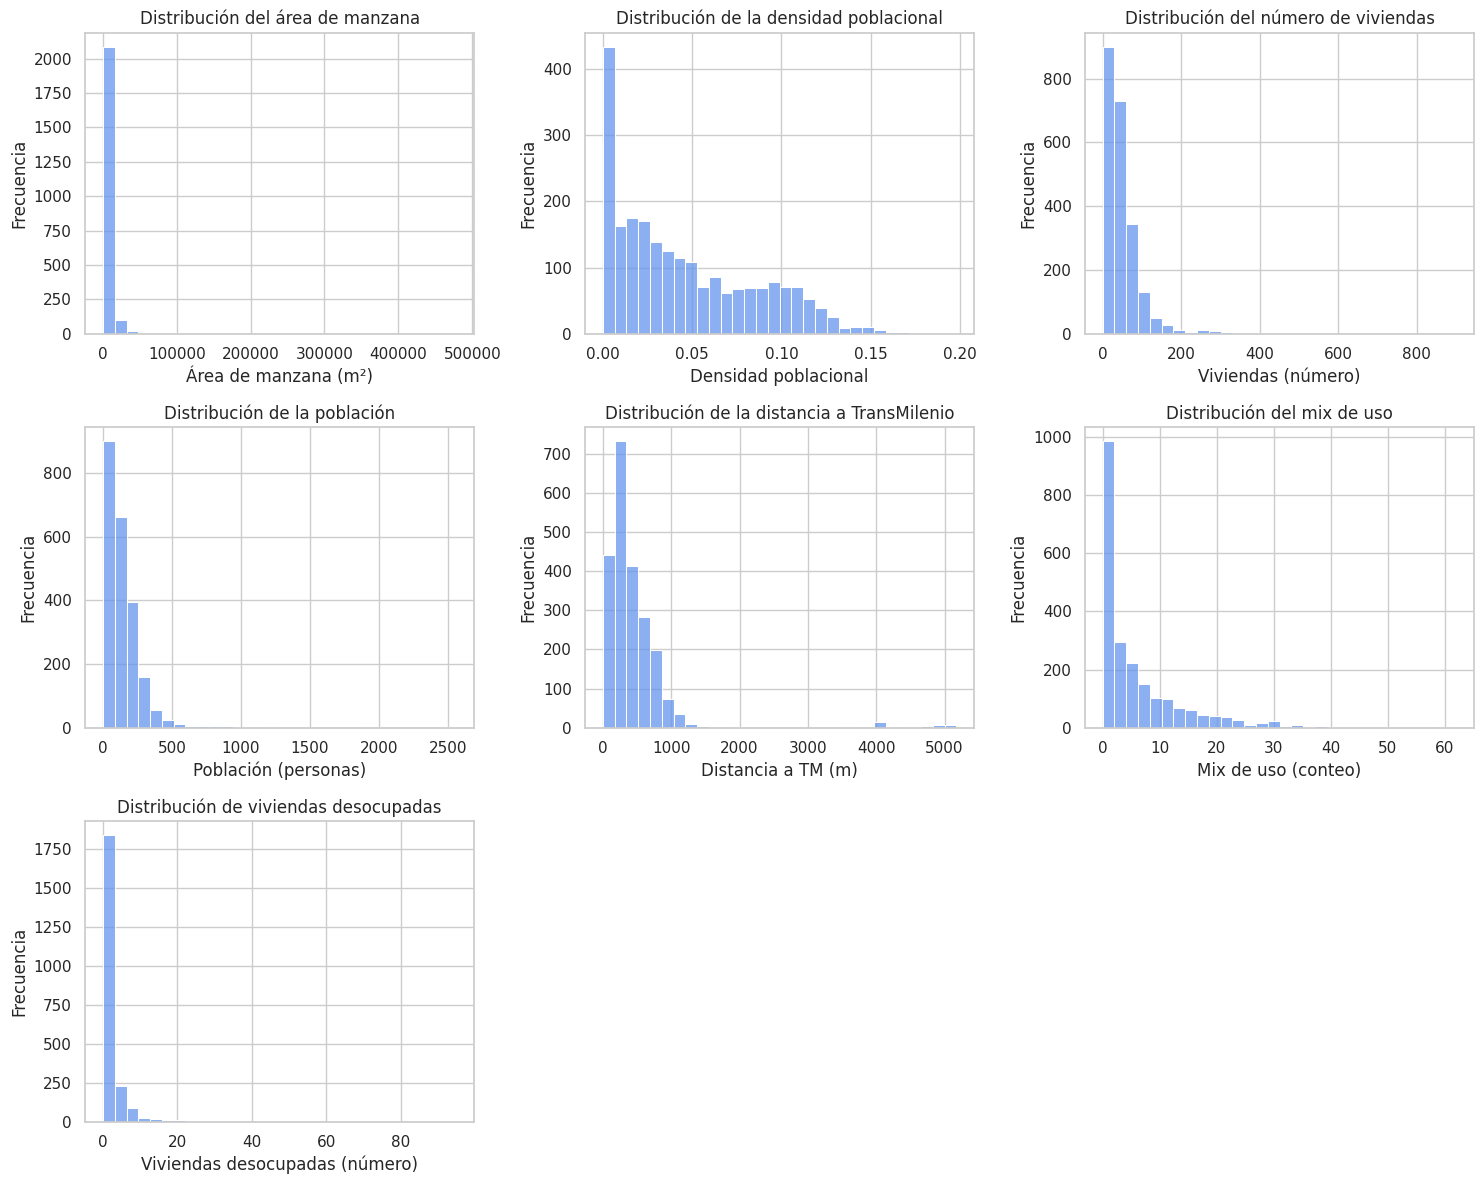

In [25]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

graficos = [
    ("area_manzana", "Distribución del área de manzana", "Área de manzana (m²)"),
    ("densidad", "Distribución de la densidad poblacional", "Densidad poblacional"),
    ("viviendas", "Distribución del número de viviendas", "Viviendas (número)"),
    ("poblacion", "Distribución de la población", "Población (personas)"),
    ("dist_tm", "Distribución de la distancia a TransMilenio", "Distancia a TM (m)"),
    ("mix_uso", "Distribución del mix de uso", "Mix de uso (conteo)"),
    ("viviendas_desocupadas", "Distribución de viviendas desocupadas", "Viviendas desocupadas (número)")
]

for i, (var, titulo, xlabel) in enumerate(graficos):
    sns.histplot(df_modelo[var], bins=30, ax=axes[i], color="cornflowerblue")
    axes[i].set_title(titulo)
    axes[i].set_xlabel(xlabel)
    axes[i].set_ylabel("Frecuencia")

for j in range(len(graficos), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Detección de valores atípicos. Boxplot

Se usan diagramas de caja para identificar valores extremos y evaluar la dispersión de las variables urbanas.

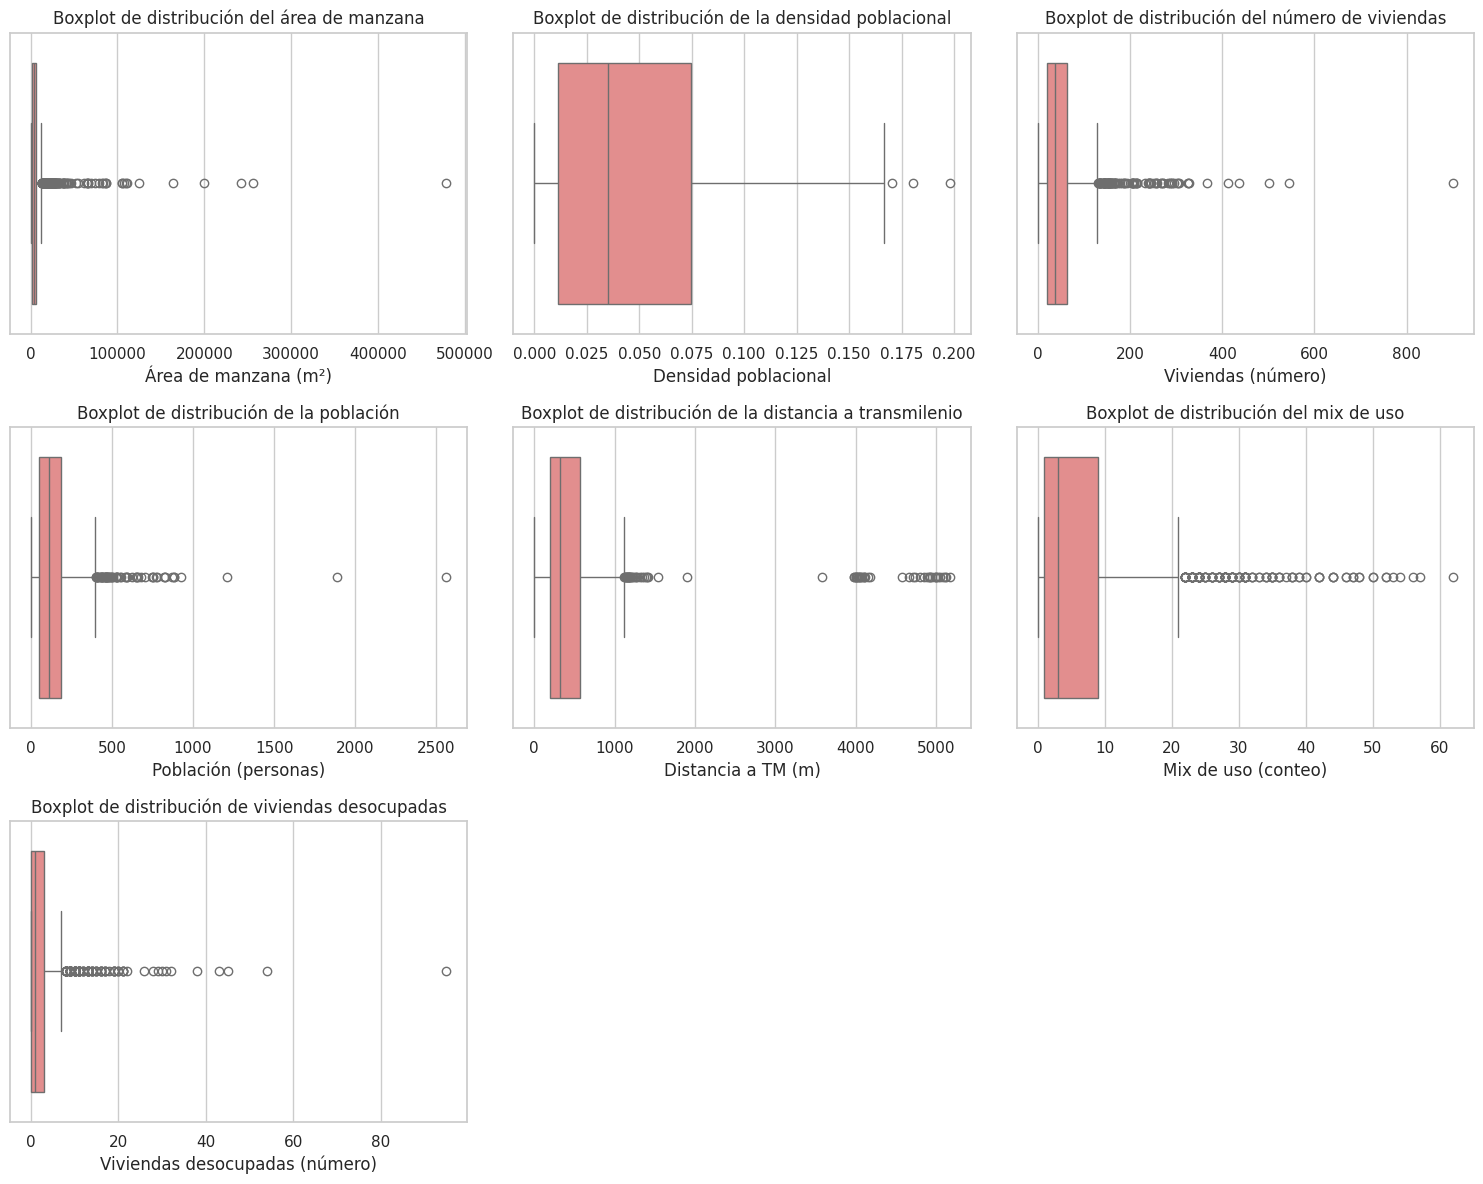

In [26]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, (var, titulo, xlabel) in enumerate(graficos):
    sns.boxplot(x=df_modelo[var], ax=axes[i], color="lightcoral")
    axes[i].set_title(f"Boxplot de {titulo.lower()}")
    axes[i].set_xlabel(xlabel)

for j in range(len(graficos), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Relación entre variables urbanas. Matriz de Correlación

Se calcula una matriz de correlación para identificar relaciones lineales entre variables y justificar la aplicación de PCA.

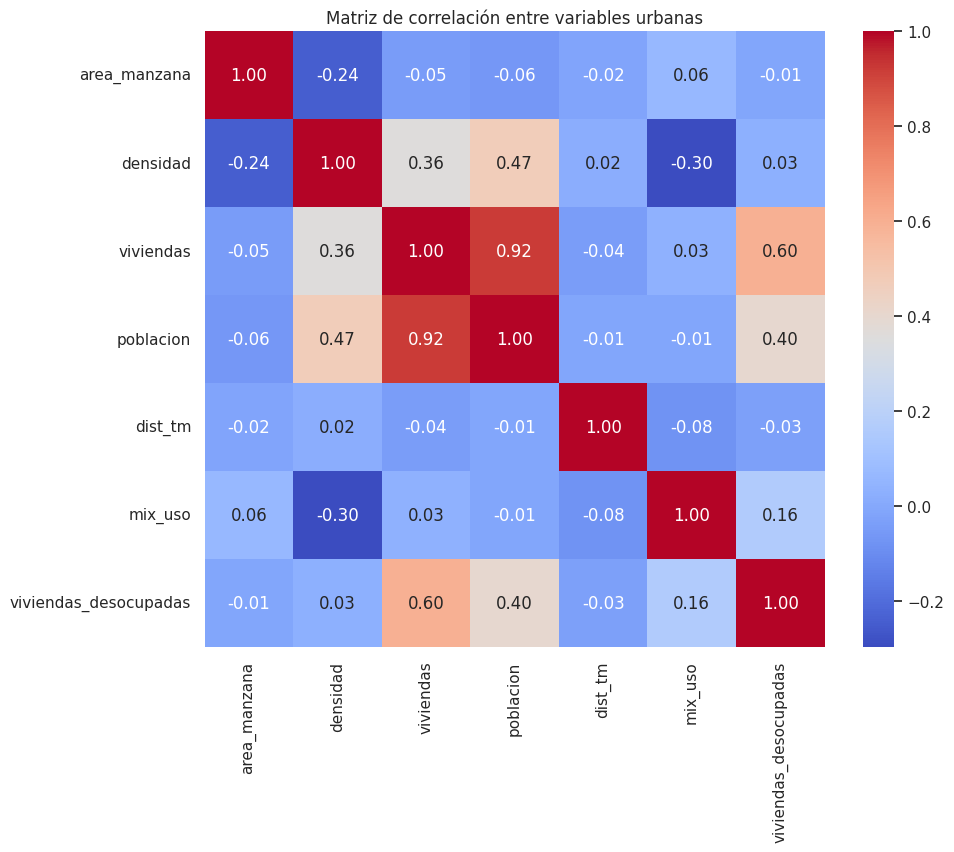

In [27]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_modelo[variables].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre variables urbanas")
plt.show()

### Interpretación de la matriz de correlación

La matriz de correlación permite identificar la relación lineal entre las variables urbanas utilizadas en el análisis. Se observa una correlación alta entre `poblacion` y `viviendas`, lo cual sugiere que ambas variables capturan parcialmente una misma dimensión del sistema urbano asociada a la intensidad residencial.

Por su parte, `densidad` presenta correlaciones moderadas con `poblacion` y `viviendas`, lo que indica que resume parte de esta intensidad urbana pero incorpora además el efecto del tamaño de la manzana. En contraste, `dist_tm` muestra correlaciones bajas con el resto de variables, lo cual sugiere que representa una dimensión distinta del territorio asociada a accesibilidad.

La variable `mix_uso`, construida como la suma de unidades no residenciales con uso comercial e industrial, se interpreta como un proxy de actividad económica no residencial en la manzana. Sus bajas correlaciones con las variables residenciales sugieren que aporta información complementaria al modelo.

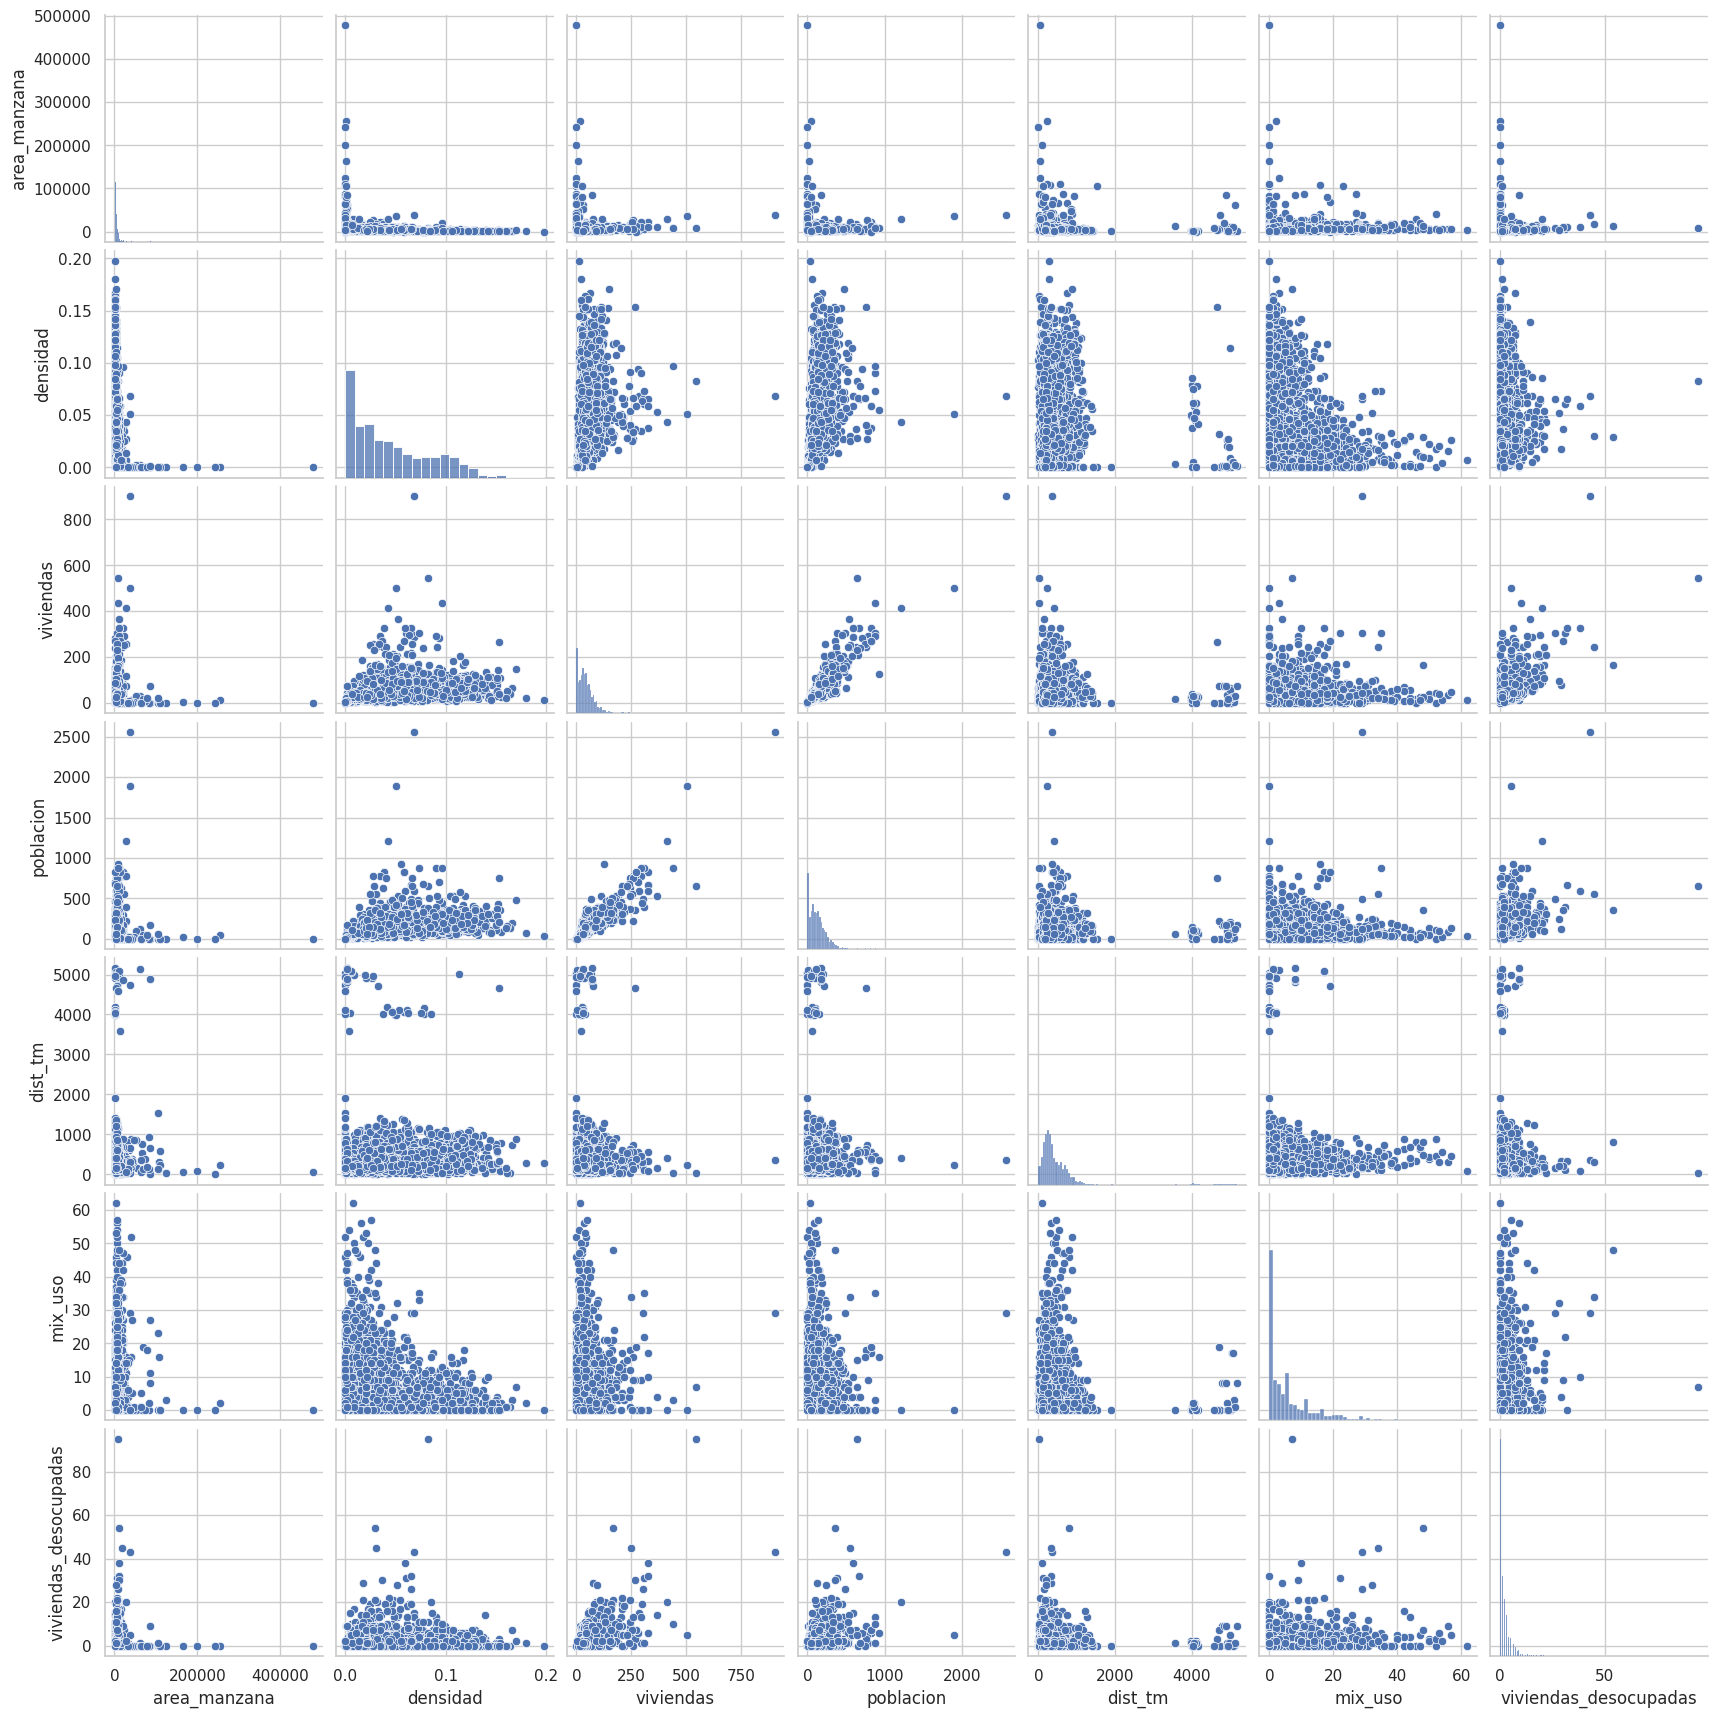

In [28]:
sns.pairplot(df_modelo[variables])
plt.show()

## Normalización de variables.  StandardScaler

Dado que las variables se encuentran en diferentes escalas y unidades (por ejemplo, metros cuadrados, personas, número de viviendas y distancias en metros), se aplica una normalización mediante StandardScaler para que ninguna variable domine el proceso de clustering.


Se aplicó una normalización mediante `StandardScaler` debido a que las variables utilizadas en el modelo presentan diferentes unidades y escalas de medición. Por ejemplo, `area_manzana` se expresa en metros cuadrados, `poblacion` en personas, `viviendas` en conteos, y `dist_tm` en metros.

Sin este proceso, variables con magnitudes numéricas más altas podrían dominar el cálculo de distancias en algoritmos como K-Means. La normalización permite que todas las variables contribuyan de manera comparable al análisis.

In [29]:
X = df_modelo[variables]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Método del codo

Se utiliza el método del codo para determinar el número adecuado de clusters en el algoritmo K-Means.

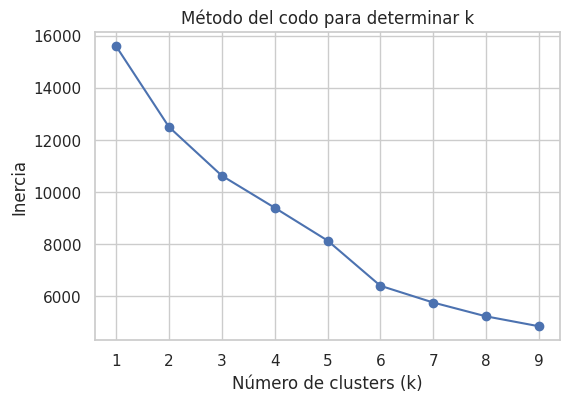

In [30]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
K = range(1,10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker='o')
plt.title("Método del codo para determinar k")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")

#
plt.savefig("codo.png", dpi=300, bbox_inches='tight')

plt.show()

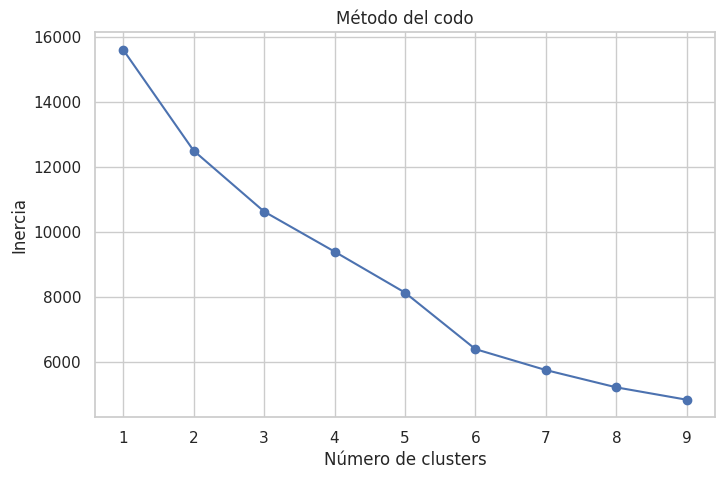

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 10), inertia, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.grid(True)
plt.show()

## Clustering con K-Means

Con base en el método del codo, se define el número de clusters y se agrupan las manzanas según similitud en sus características urbanas.

In [32]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_modelo["cluster"] = kmeans.fit_predict(X_scaled)

In [33]:
df_modelo["cluster"].value_counts()

,count
cluster,
0,1201
2,954
1,73


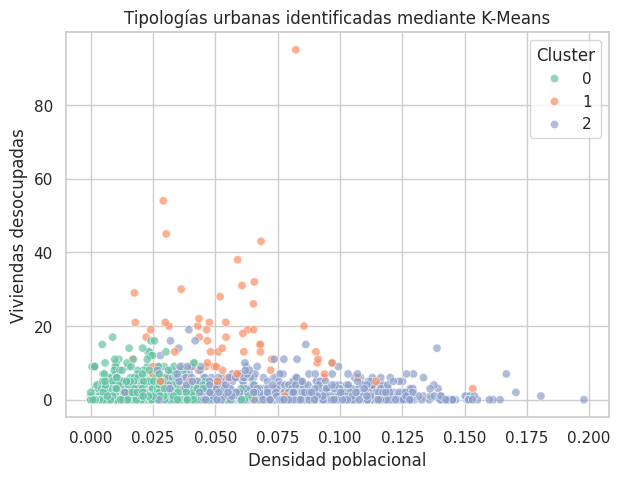

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df_modelo,
    x="densidad",
    y="viviendas_desocupadas",
    hue="cluster",
    palette="Set2",
    alpha=0.7
)

plt.title("Tipologías urbanas identificadas mediante K-Means")
plt.xlabel("Densidad poblacional")
plt.ylabel("Viviendas desocupadas")
plt.legend(title="Cluster")

plt.savefig("clusters.png", dpi=300, bbox_inches="tight")
plt.show()

## Caracterización de tipologias urbanas mediante K-Means/Clusters

Los clusters identificados mediante el algoritmo K-Means representan tipologías urbanas de manzanas con características similares en términos de densidad, población, usos de la vivienda y accesibilidad al sistema de transporte masivo.

El objetivo del clustering no es establecer directamente la prioridad de intervención, sino identificar patrones territoriales dentro del conjunto de manzanas analizadas. Posteriormente, la priorización de renovación urbana se calcula mediante un índice de puntuación (score de renovación) construido a partir de variables urbanas relevantes.

In [35]:
df_modelo.groupby("cluster")[variables].mean().round(3)

,area_manzana,densidad,viviendas,poblacion,dist_tm,mix_uso,viviendas_desocupadas
cluster,,,,,,,
0,9101.506,0.016,24.482,63.689,411.284,8.869,1.479
1,9440.305,0.056,234.082,534.575,357.752,9.822,15.479
2,2867.105,0.081,63.647,195.904,527.243,3.037,1.832


**Distribución de clusters por actuación estratégica**

In [36]:
tabla_clusters_ae = pd.crosstab(df_modelo["actuacion_estrategica"], df_modelo["cluster"])

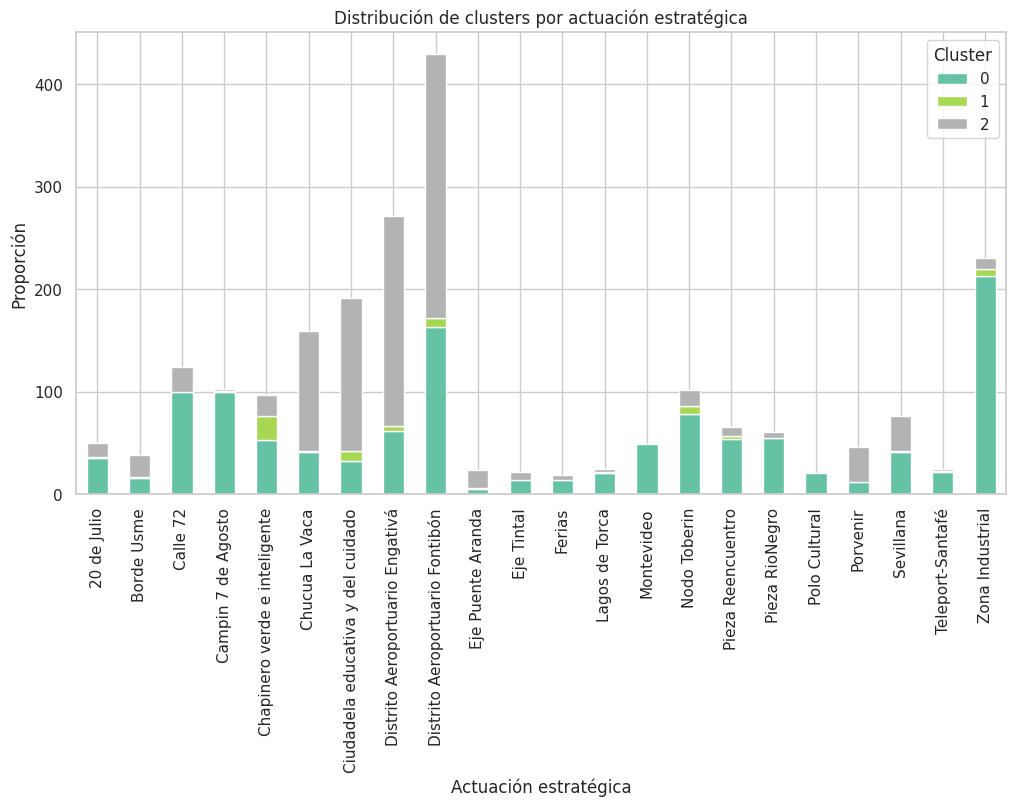

In [37]:
tabla_clusters_ae.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    colormap="Set2"
)

plt.title("Distribución de clusters por actuación estratégica")
plt.xlabel("Actuación estratégica")
plt.ylabel("Proporción")
plt.legend(title="Cluster")
plt.show()

# Silhouette Score

El valor de Silhouette obtenido (≈0.28) indica una separación moderada entre clusters, lo cual es consistente con la naturaleza continua de las variables urbanas. En contextos territoriales, donde las transiciones espaciales suelen ser graduales, este resultado sugiere que los clusters identificados representan tipologías urbanas con cierto grado de solapamiento


In [38]:


from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df_modelo["cluster"])

print("Silhouette score:", score)


Silhouette score: 0.28229119087869026


# Construcción del índice de renovación urbana

La priorización final se realiza mediante un índice multicriterio que integra cuatro dimensiones territoriales:

- Vacancia residencial (45%)
- Accesibilidad al transporte masivo (30%)
- Densidad poblacional inversa (20%)
- Mezcla de usos del suelo (5%)

Se privilegian las manzanas con mayor presencia de viviendas desocupadas, mayor accesibilidad, menor densidad poblacional y mayor diversidad funcional.

In [39]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

vars_score = [
    "viviendas_desocupadas",
    "densidad",
    "poblacion",
    "dist_tm",
    "mix_uso"
]

scaler = MinMaxScaler()

norm = scaler.fit_transform(df_modelo[vars_score])

norm = pd.DataFrame(norm, columns=[v+"_norm" for v in vars_score])

df_modelo = pd.concat([df_modelo.reset_index(drop=True), norm], axis=1)

In [40]:
df_modelo["score_renovacion"] = (
    df_modelo["viviendas_desocupadas_norm"] * 0.45 +
    (1 - df_modelo["dist_tm_norm"]) * 0.30 +
    (1 - df_modelo["densidad_norm"]) * 0.20 +
    df_modelo["mix_uso_norm"] * 0.05
)

## Clasificación final de prioridades

A partir de la distribución del índice, las manzanas se clasifican en tres niveles de prioridad: baja, media y alta.

In [41]:
q1 = df_modelo["score_renovacion"].quantile(0.33)
q2 = df_modelo["score_renovacion"].quantile(0.66)

def clasificar_prioridad(score):

    if score <= q1:
        return "baja"

    elif score <= q2:
        return "media"

    else:
        return "alta"

df_modelo["prioridad_final"] = df_modelo["score_renovacion"].apply(clasificar_prioridad)

In [42]:
df_modelo["prioridad_final"].value_counts()

,count
prioridad_final,
alta,758
media,735
baja,735


In [43]:
df_modelo.groupby("prioridad_final")[[
    "viviendas_desocupadas",
    "densidad",
    "poblacion",
    "dist_tm"
]].mean().round(2)

,viviendas_desocupadas,densidad,poblacion,dist_tm
prioridad_final,,,,
alta,3.28,0.01,82.75,251.87
baja,1.16,0.09,183.55,718.70
media,1.79,0.04,142.55,413.47


<Figure size 1000x600 with 0 Axes>

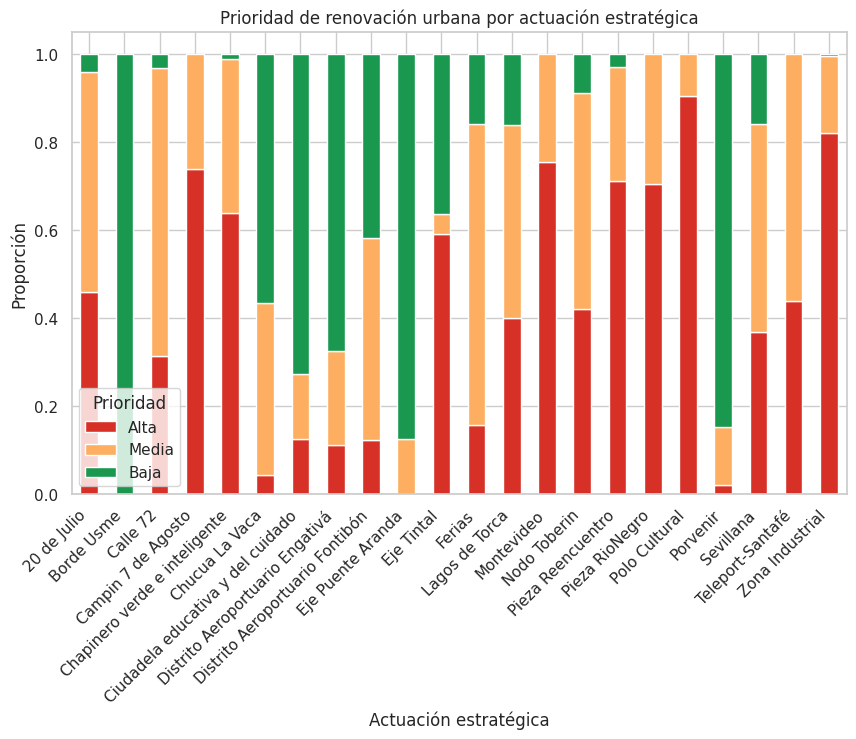

In [44]:
import matplotlib.pyplot as plt

# Asegurar nombres correctos
df_modelo["prioridad_final"] = df_modelo["prioridad_final"].astype(str).str.strip().str.capitalize()

# Agrupar por actuación estratégica
tabla = (
    df_modelo
    .groupby(["actuacion_estrategica", "prioridad_final"])
    .size()
    .unstack(fill_value=0)
)

# Convertir a proporciones
tabla = tabla.div(tabla.sum(axis=1), axis=0)

# Orden de categorías
orden_cols = ["Alta", "Media", "Baja"]
tabla = tabla[orden_cols]

# Paleta
colores = ["#d73027", "#fdae61", "#1a9850"]

# Gráfico
plt.figure(figsize=(10,6))
tabla.plot(
    kind="bar",
    stacked=True,
    color=colores,
    figsize=(10,6)
)

plt.title("Prioridad de renovación urbana por actuación estratégica")
plt.xlabel("Actuación estratégica")
plt.ylabel("Proporción")
plt.legend(title="Prioridad")

plt.xticks(rotation=45, ha="right")

plt.savefig("prioridad_ae.png", dpi=300, bbox_inches='tight')
plt.show()

In [45]:
df_modelo.groupby("prioridad_final")[[
    "viviendas_desocupadas",
    "densidad",
    "poblacion",
    "dist_tm"
]].mean().round(2)



,viviendas_desocupadas,densidad,poblacion,dist_tm
prioridad_final,,,,
Alta,3.28,0.01,82.75,251.87
Baja,1.16,0.09,183.55,718.70
Media,1.79,0.04,142.55,413.47


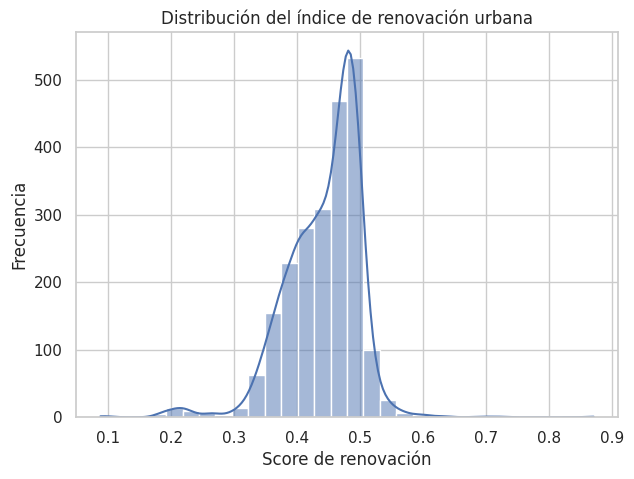

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.histplot(
    df_modelo["score_renovacion"],
    bins=30,
    kde=True
)

plt.title("Distribución del índice de renovación urbana")
plt.xlabel("Score de renovación")
plt.ylabel("Frecuencia")

plt.savefig("histograma.png", dpi=300, bbox_inches='tight')
plt.show()

In [47]:
df_modelo.columns

Index(['objectid', 'man_codigo', 'actuacion_estrategica', 'ae_priorizada',
       'cod_dane', 'area_manzana', 'densidad', 'viviendas', 'poblacion',
       'dist_tm', 'mix_uso', 'cantidad_encuestas', 'uso_residencial',
       'uso_industrial', 'uso_comercial', 'viviendas_desocupadas',
       'tiene_parque', 'tiene_equipa_pub', 'tiene_esp_pub', 'tiene_aim',
       'plan_parcial_excluido', 'estado_pp', 'tiene_bic', 'sum_exclusiones',
       'calificables', 'cluster', 'viviendas_desocupadas_norm',
       'densidad_norm', 'poblacion_norm', 'dist_tm_norm', 'mix_uso_norm',
       'score_renovacion', 'prioridad_final'],
      dtype='object')

In [48]:
df_modelo.head()

,objectid,man_codigo,actuacion_estrategica,ae_priorizada,cod_dane,area_manzana,densidad,viviendas,poblacion,dist_tm,...,sum_exclusiones,calificables,cluster,viviendas_desocupadas_norm,densidad_norm,poblacion_norm,dist_tm_norm,mix_uso_norm,score_renovacion,prioridad_final
0,1,8544012,Lagos de Torca,0,1100110000000085330115,9850.528979,0.048472,190.0,492.0,211.750049,...,0.0,1.0,1,0.010526,0.244870,0.192112,0.040934,0.177419,0.452354,Media
1,2,8519059,Nodo Toberin,0,1100110000000085190312,3952.997481,0.013165,20.0,52.0,826.160220,...,0.0,1.0,0,0.021053,0.066506,0.020305,0.159708,0.016129,0.449067,Media
2,3,8516029,Nodo Toberin,0,1100110000000085160107,6712.437990,0.027434,50.0,184.0,773.151617,...,0.0,1.0,0,0.021053,0.138590,0.071847,0.149461,0.080645,0.440950,Media
3,4,8516019,Nodo Toberin,0,1100110000000085160201,21563.511592,0.038000,325.0,822.0,567.918018,...,0.0,1.0,1,0.063158,0.191969,0.320968,0.109786,0.274194,0.470801,Media
4,5,8501008,Nodo Toberin,0,1100110000000085010206,17517.294260,0.005901,47.0,100.0,238.909162,...,0.0,1.0,0,0.000000,0.029810,0.039047,0.046184,0.612903,0.510828,Alta


In [49]:
columnas_finales = [
    "man_codigo",
    "actuacion_estrategica",
    "viviendas_desocupadas",
    "densidad",
    "poblacion",
    "dist_tm",
    "mix_uso",
    "score_renovacion",
    "prioridad_final"
]

df_modelo[columnas_finales].to_excel("resultado_priorizacion_final.xlsx", index=False)

## Exportación de resultados

La tabla final se exporta para su posterior unión espacial en ArcGIS mediante el campo `cod_dane`, con el fin de representar cartográficamente el score y la prioridad final por actuación estratégica.

In [50]:
df_modelo.to_excel("resultado_priorizacion_final.xlsx", index=False)

# RESULTADOS DEL MODELO

El flujo analítico permitió identificar manzanas con potencial de renovación urbana a partir de un enfoque multicriterio aplicado sobre unidades previamente filtradas por viabilidad normativa.

El clustering se utilizó como herramienta exploratoria para identificar tipologías urbanas, mientras que la priorización final se obtuvo mediante un índice compuesto por vacancia residencial, accesibilidad al transporte, densidad poblacional inversa y mezcla de usos del suelo.

Los resultados exportados permiten su integración en ArcGIS para la generación de mapas por actuación estratégica.

In [51]:
df_modelo["prioridad_final"].value_counts()

,count
prioridad_final,
Alta,758
Media,735
Baja,735


In [52]:
df_modelo["prioridad_final"].value_counts(normalize=True).round(3) * 100

,proportion
prioridad_final,
Alta,34.0
Media,33.0
Baja,33.0


In [53]:
df_modelo.groupby("prioridad_final")[[
    "viviendas_desocupadas",
    "densidad",
    "poblacion",
    "dist_tm",
    "mix_uso"
]].mean().round(2)

,viviendas_desocupadas,densidad,poblacion,dist_tm,mix_uso
prioridad_final,,,,,
Alta,3.28,0.01,82.75,251.87,11.23
Baja,1.16,0.09,183.55,718.70,2.47
Media,1.79,0.04,142.55,413.47,5.36


In [54]:
df_modelo["score_renovacion"].describe().round(3)

,score_renovacion
count,2228.000
mean,0.443
std,0.060
min,0.088
25%,0.406
50%,0.456
75%,0.485
max,0.871


In [55]:
tabla_prioridad_ae = pd.crosstab(
    df_modelo["actuacion_estrategica"],
    df_modelo["prioridad_final"],
    normalize="index"
)

tabla_prioridad_ae.round(2)

prioridad_final,Alta,Baja,Media
actuacion_estrategica,,,
20 de Julio,0.46,0.04,0.50
Borde Usme,0.00,1.00,0.00
Calle 72,0.31,0.03,0.65
Campin 7 de Agosto,0.74,0.00,0.26
Chapinero verde e inteligente,0.64,0.01,0.35
Chucua La Vaca,0.04,0.57,0.39
Ciudadela educativa y del cuidado,0.13,0.73,0.15
Distrito Aeroportuario Engativá,0.11,0.68,0.21
Distrito Aeroportuario Fontibón,0.12,0.42,0.46


In [56]:
df_modelo["prioridad_final"].unique()

array(['Media', 'Alta', 'Baja'], dtype=object)

In [57]:
df_modelo["prioridad_final"] = df_modelo["prioridad_final"].astype(str).str.strip().str.capitalize()

In [58]:
df_modelo["prioridad_final"].value_counts()

,count
prioridad_final,
Alta,758
Media,735
Baja,735


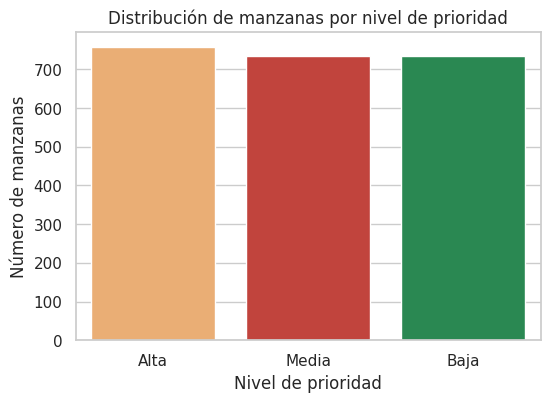

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=df_modelo,
    x="prioridad_final",
    hue="prioridad_final",
    order=["Alta", "Media", "Baja"],
    palette=["#d73027", "#fdae61", "#1a9850"],
    legend=False
)

plt.title("Distribución de manzanas por nivel de prioridad")
plt.xlabel("Nivel de prioridad")
plt.ylabel("Número de manzanas")

plt.savefig("barras.png", dpi=300, bbox_inches='tight')
plt.show()

## Scatter de resultados del modelo

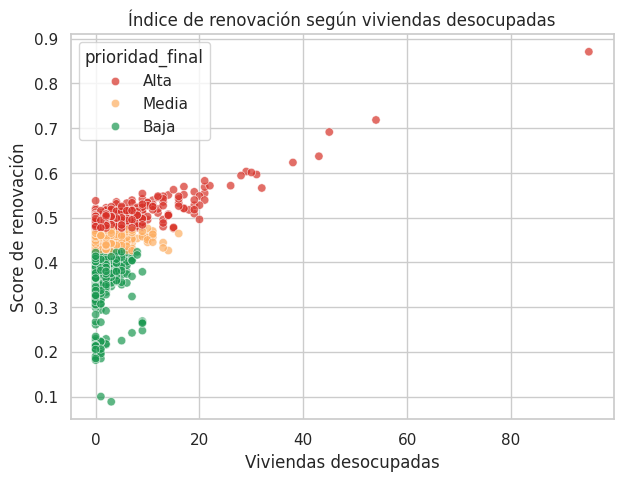

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df_modelo,
    x="viviendas_desocupadas",
    y="score_renovacion",
    hue="prioridad_final",
    hue_order=["Alta", "Media", "Baja"],
    palette={
        "Alta": "#d73027",
        "Media": "#fdae61",
        "Baja": "#1a9850"
    },
    alpha=0.7
)

plt.title("Índice de renovación según viviendas desocupadas")
plt.xlabel("Viviendas desocupadas")
plt.ylabel("Score de renovación")

plt.savefig("scatter_vacancia.png", dpi=300, bbox_inches="tight")
plt.show()

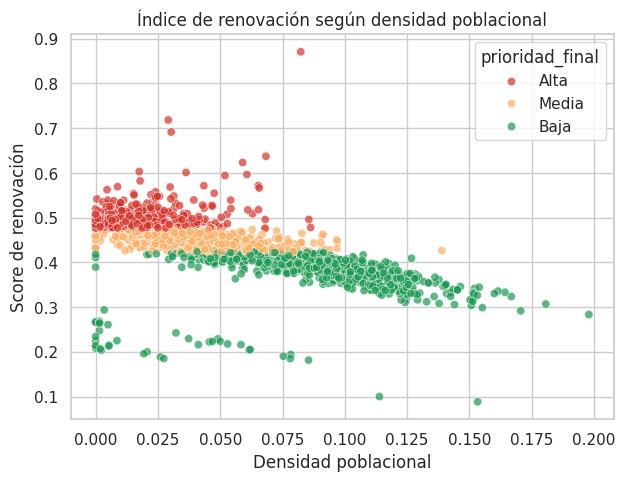

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df_modelo,
    x="densidad",
    y="score_renovacion",
    hue="prioridad_final",
    hue_order=["Alta", "Media", "Baja"],
    palette={
        "Alta": "#d73027",
        "Media": "#fdae61",
        "Baja": "#1a9850"
    },
    alpha=0.7
)

plt.title("Índice de renovación según densidad poblacional")
plt.xlabel("Densidad poblacional")
plt.ylabel("Score de renovación")

plt.savefig("scatter_densidad.png", dpi=300, bbox_inches="tight")
plt.show()

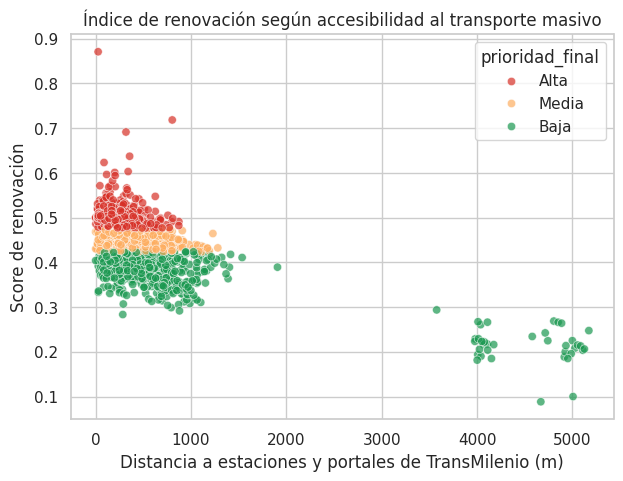

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df_modelo,
    x="dist_tm",
    y="score_renovacion",
    hue="prioridad_final",
    hue_order=["Alta", "Media", "Baja"],
    palette={
        "Alta": "#d73027",
        "Media": "#fdae61",
        "Baja": "#1a9850"
    },
    alpha=0.7
)

plt.title("Índice de renovación según accesibilidad al transporte masivo")
plt.xlabel("Distancia a estaciones y portales de TransMilenio (m)")
plt.ylabel("Score de renovación")

plt.savefig("scatter_transporte.png", dpi=300, bbox_inches="tight")
plt.show()

La figura muestra la distribución de las manzanas según densidad poblacional y distancia al sistema de transporte masivo. Los colores representan la prioridad de renovación urbana asignada por el modelo. Se observa que las manzanas clasificadas con prioridad alta tienden a concentrarse en áreas con menor densidad poblacional y buena accesibilidad al transporte, lo cual coincide con el objetivo del modelo de identificar zonas con mayor potencial de intervención y menor impacto en términos de desplazamiento de población

## Box Plot por prioridad

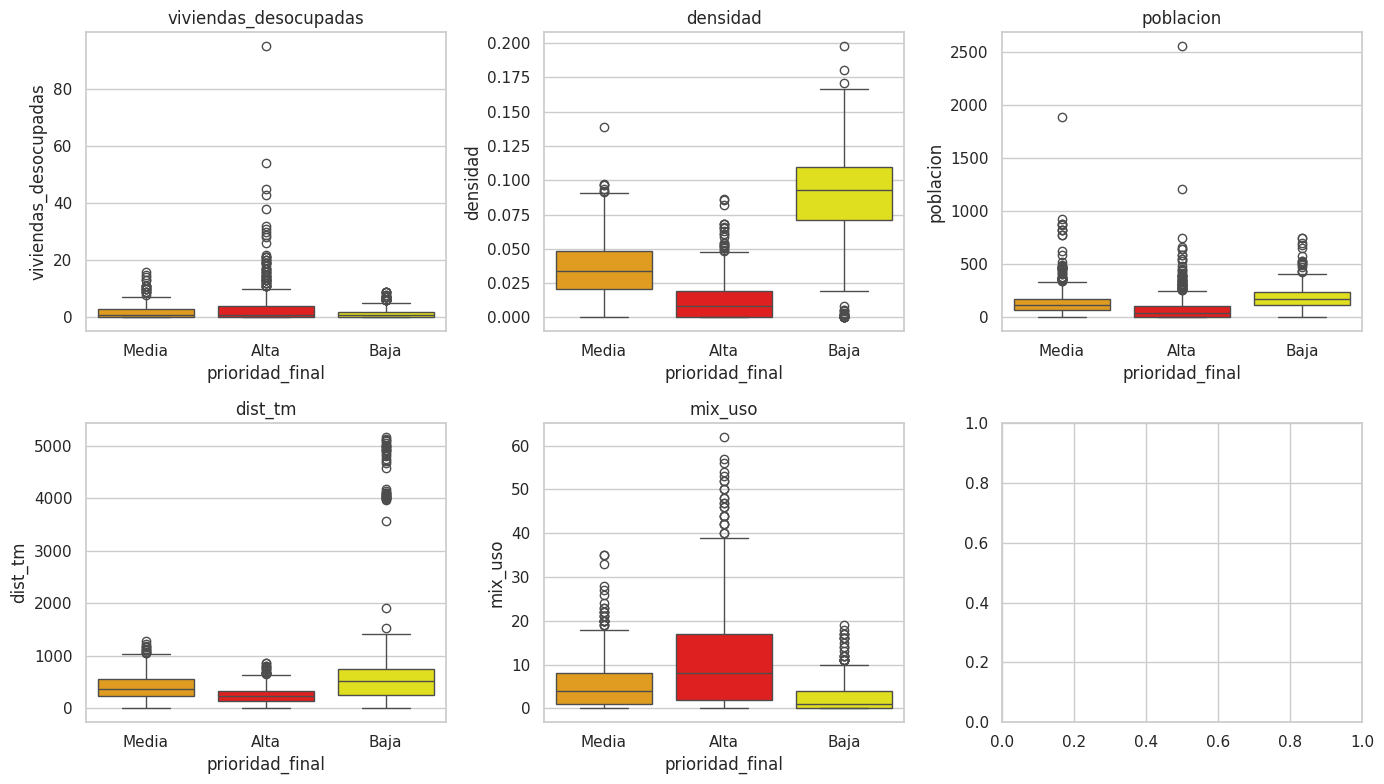

In [66]:
variables = [
    "viviendas_desocupadas",
    "densidad",
    "poblacion",
    "dist_tm",
    "mix_uso"
]

fig, axes = plt.subplots(2,3, figsize=(14,8))

axes = axes.flatten()

for i, var in enumerate(variables):

    sns.boxplot(
        data=df_modelo,
        x="prioridad_final",
        y=var,
        hue="prioridad_final", # Added to comply with future Seaborn API
        palette={"Alta":"red","Media":"orange","Baja":"yellow"},
        legend=False, # Added to comply with future Seaborn API
        ax=axes[i]
    )

    axes[i].set_title(var)

plt.tight_layout()
plt.show()

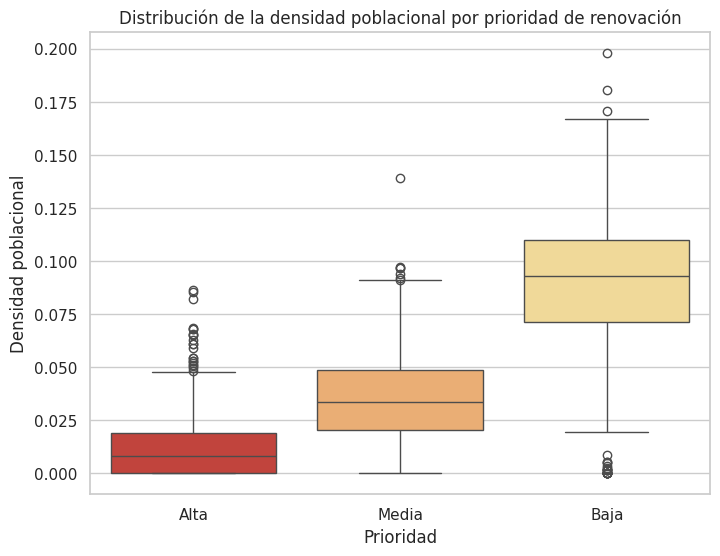

In [67]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_modelo,
    x="prioridad_final",
    y="densidad",
    hue="prioridad_final", # Added to comply with future Seaborn API
    order=["Alta","Media","Baja"], # Corrected case to match df_modelo['prioridad_final']
    palette={"Alta":"#d73027","Media":"#fdae61","Baja":"#fee08b"}, # Corrected case
    legend=False # Added to comply with future Seaborn API
)

plt.title("Distribución de la densidad poblacional por prioridad de renovación")
plt.xlabel("Prioridad")
plt.ylabel("Densidad poblacional")
plt.show()

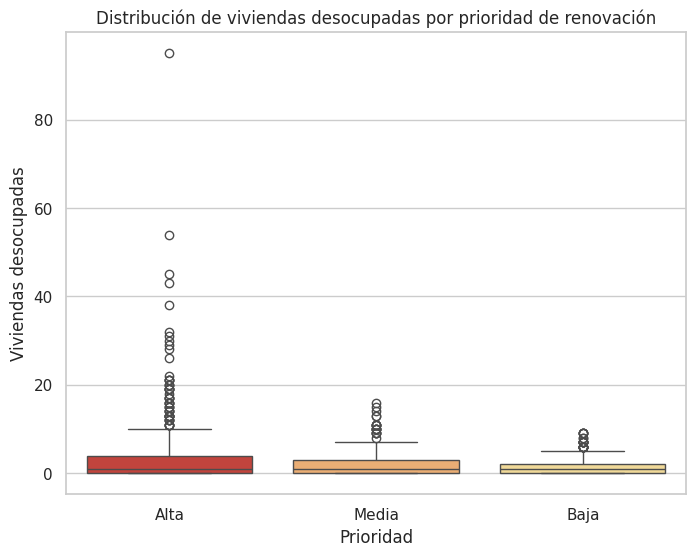

In [68]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_modelo,
    x="prioridad_final",
    y="viviendas_desocupadas",
    hue="prioridad_final", # Added to comply with future Seaborn API
    order=["Alta","Media","Baja"], # Corrected case to match df_modelo['prioridad_final']
    palette={"Alta":"#d73027","Media":"#fdae61","Baja":"#fee08b"}, # Corrected case
    legend=False # Added to comply with future Seaborn API
)

plt.title("Distribución de viviendas desocupadas por prioridad de renovación")
plt.xlabel("Prioridad")
plt.ylabel("Viviendas desocupadas")
plt.show()

# Histograma del Score

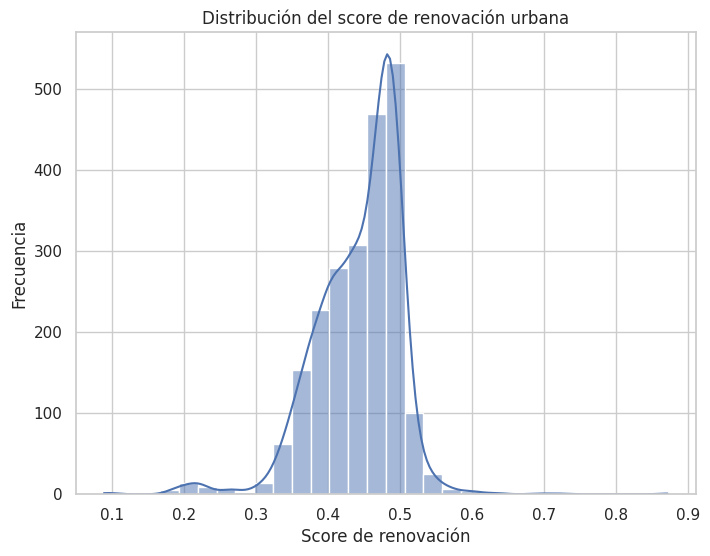

In [70]:
plt.figure(figsize=(8,6))

sns.histplot(
    data=df_modelo,
    x="score_renovacion",
    bins=30,
    kde=True
)

plt.title("Distribución del score de renovación urbana")
plt.xlabel("Score de renovación")
plt.ylabel("Frecuencia")
plt.show()


# Promedio de variable



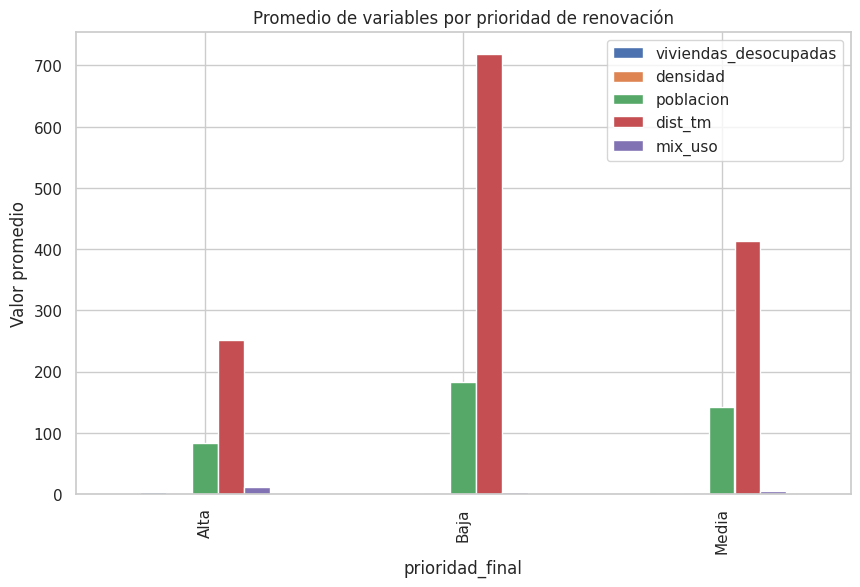

In [71]:
tabla = df_modelo.groupby("prioridad_final")[[
    "viviendas_desocupadas",
    "densidad",
    "poblacion",
    "dist_tm",
    "mix_uso"
]].mean()

tabla.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Promedio de variables por prioridad de renovación")
plt.ylabel("Valor promedio")

plt.show()


In [72]:
tabla_resultados = df_modelo.groupby("prioridad_final")[[
    "viviendas_desocupadas",
    "densidad",
    "poblacion",
    "dist_tm",
    "mix_uso"
]].mean().round(2)

tabla_resultados


,viviendas_desocupadas,densidad,poblacion,dist_tm,mix_uso
prioridad_final,,,,,
Alta,3.28,0.01,82.75,251.87,11.23
Baja,1.16,0.09,183.55,718.70,2.47
Media,1.79,0.04,142.55,413.47,5.36


In [73]:
df_modelo[[
    "score_renovacion",
    "viviendas_desocupadas",
    "densidad",
    "poblacion",
    "dist_tm",
    "mix_uso"
]].corr()


,score_renovacion,viviendas_desocupadas,densidad,poblacion,dist_tm,mix_uso
score_renovacion,1.000000,0.357530,-0.708572,-0.172085,-0.611377,0.414509
viviendas_desocupadas,0.357530,1.000000,0.029631,0.398581,-0.030428,0.160428
densidad,-0.708572,0.029631,1.000000,0.468248,0.020348,-0.298416
poblacion,-0.172085,0.398581,0.468248,1.000000,-0.013589,-0.009329
dist_tm,-0.611377,-0.030428,0.020348,-0.013589,1.000000,-0.076318
mix_uso,0.414509,0.160428,-0.298416,-0.009329,-0.076318,1.000000


<Axes: xlabel='prioridad_final', ylabel='score_renovacion'>

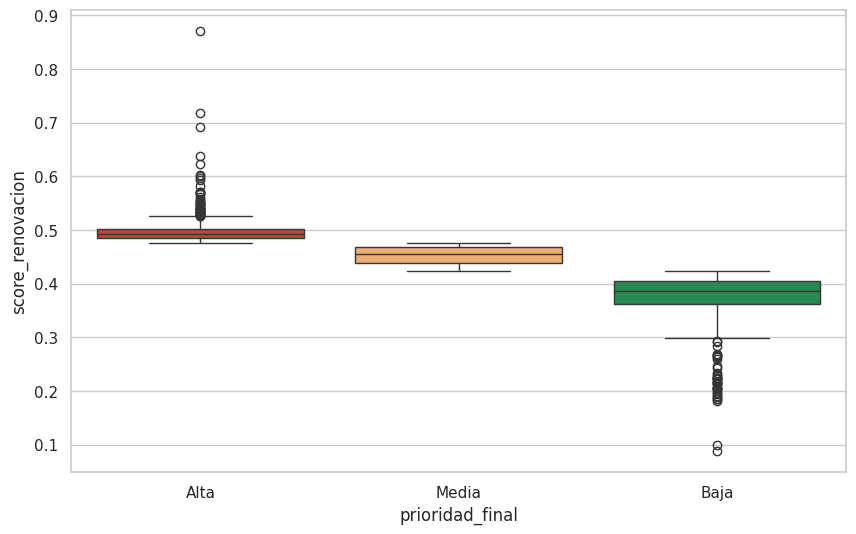

In [69]:
sns.boxplot(
    data=df_modelo,
    x="prioridad_final",
    y="score_renovacion",
    hue="prioridad_final", # Added to comply with future Seaborn API
    order=["Alta", "Media", "Baja"], # Explicitly setting order
    palette={"Alta":"#d73027","Media":"#fdae61","Baja":"#1a9850"}, # Using consistent palette
    legend=False # Added to comply with future Seaborn API
)

In [74]:
df_modelo.groupby("prioridad_final")[[    "viviendas_desocupadas",    "densidad",    "poblacion",    "dist_tm",    "mix_uso"]].mean()

,viviendas_desocupadas,densidad,poblacion,dist_tm,mix_uso
prioridad_final,,,,,
Alta,3.284960,0.012466,82.745383,251.865571,11.230871
Baja,1.156463,0.088929,183.551020,718.695693,2.472109
Media,1.787755,0.035335,142.552381,413.472310,5.355102
